# AARES PROJECT

## Partie 1

### Exercice 1

####  Objectif

L’objectif de cet exercice est de construire un modèle de classification capable de prédire le genre musical d’un morceau à partir de ses caractéristiques audio issues de Spotify.

Nous utiliserons uniquement les variables numériques comme variables explicatives (X), tandis que la variable genre sera définie comme variable cible (y).

Les performances des différents modèles seront évaluées à l’aide du F1-score, métrique adaptée à la classification multi-classe.


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt





#### 1.1 Exploration et analyse du dataset

Dans cette première étape, nous chargeons le jeu de données d’entraînement et réalisons une analyse exploratoire.

L’objectif est de :
- examiner la structure du dataset,
- identifier les variables disponibles,
- analyser la distribution de la variable cible genre,
- observer certaines variables explicatives comme explicit.

Cette exploration permet de mieux comprendre la nature des données avant d’entraîner les modèles.



  release_date  explicit  popularity  danceability  energy  key  loudness  \
0   2015-06-23     False          38         0.509  0.8720    2    -5.170   
1   2021-11-12     False          58         0.182  0.0377   11   -33.748   
2   2013-06-21     False          36         0.550  0.9410    0    -3.128   
3   2012-09-04     False           0         0.569  0.7190    6    -8.399   
4         2008     False           0         0.631  0.6610    8    -5.694   

   mode  speechiness  acousticness  instrumentalness  liveness  valence  \
0     1       0.0547        0.0396          0.000015    0.3310   0.4860   
1     0       0.0391        0.9870          0.957000    0.0804   0.0923   
2     0       0.0849        0.0182          0.003750    0.3120   0.3510   
3     0       0.0663        0.8670          0.941000    0.1760   0.6430   
4     1       0.0558        0.0146          0.720000    0.3650   0.3300   

     tempo  duration_ms  time_signature      genre  
0   95.969       194375          

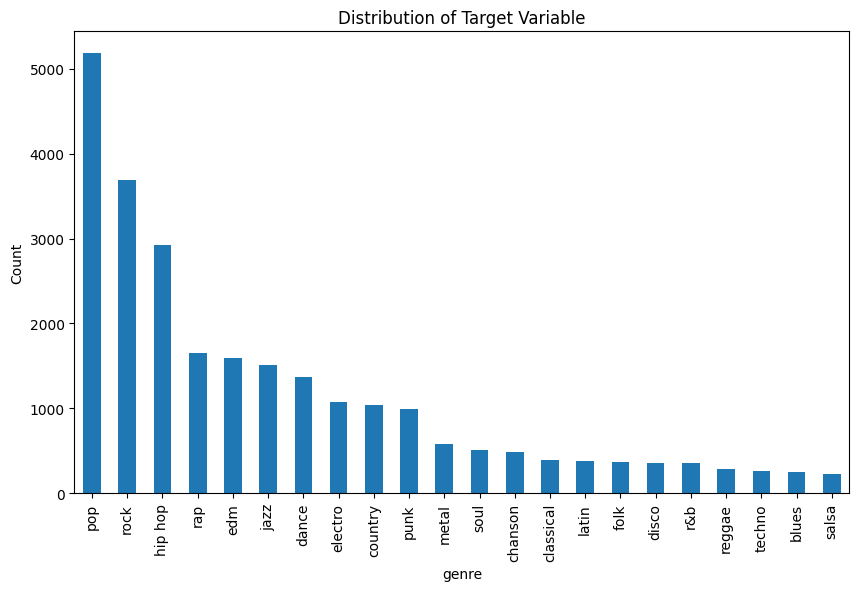

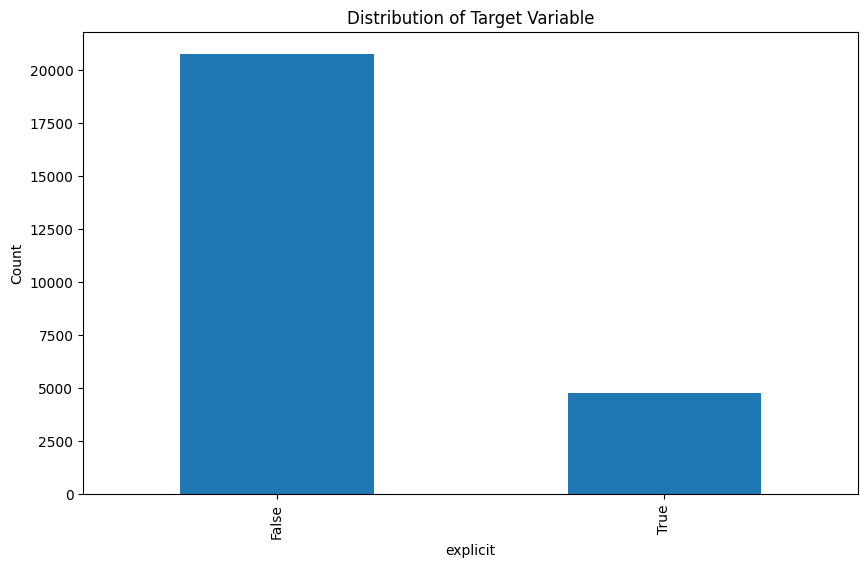

  release_date  explicit  popularity  danceability  energy  key  loudness  \
0   2015-06-23     False          38         0.509  0.8720    2    -5.170   
1   2021-11-12     False          58         0.182  0.0377   11   -33.748   
2   2013-06-21     False          36         0.550  0.9410    0    -3.128   
3   2012-09-04     False           0         0.569  0.7190    6    -8.399   
4         2008     False           0         0.631  0.6610    8    -5.694   

   mode  speechiness  acousticness  instrumentalness  liveness  valence  \
0     1       0.0547        0.0396          0.000015    0.3310   0.4860   
1     0       0.0391        0.9870          0.957000    0.0804   0.0923   
2     0       0.0849        0.0182          0.003750    0.3120   0.3510   
3     0       0.0663        0.8670          0.941000    0.1760   0.6430   
4     1       0.0558        0.0146          0.720000    0.3650   0.3300   

     tempo  duration_ms  time_signature      genre  
0   95.969       194375          

In [19]:
# load the dataset

df = pd.read_csv(r"C:\Users\yanis\Documents\TP AARES\dataset_part_1\dataset\spotify_dataset_train.csv")

# Data exploration

print (df.head())


print(df.columns)

# Focus on the target variable 'genre'

print(df.describe())
plt.figure(figsize=(10, 6))
df['genre'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable')
plt.xlabel('genre')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
df['explicit'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable')
plt.xlabel('explicit')
plt.ylabel('Count')
plt.show()

print (df.head())
print (df.info())
print(df.columns)
print (df.describe().T)

#### 1.2 Entraînement et comparaison des modèles

Les variables numériques présentent des échelles différentes (ex : duration_ms, danceability, loudness).  
Une normalisation via StandardScaler est donc appliquée afin d’éviter qu’une variable domine les autres.

Plusieurs modèles sont ensuite entraînés et comparés :
- KNN
- Régression Logistique
- SVM
- Random Forest
- XGBoost

Les performances sont évaluées à l’aide du F1-score.


In [20]:
#Test KNN

y = df["genre"]
X = df.drop(columns=["genre","release_date"])
X.shape, y.shape
X.dtypes

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=10,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_val_scaled)
f1 = f1_score(y_val, y_pred, average="micro")
f1






0.33594822514218475

In [21]:
#Test Random Forest

rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
f1_rf = f1_score(y_val, y_pred_rf, average="micro")
f1_rf


0.4447930966856246

In [22]:
#Test SVM

svm = SVC(kernel="rbf",C=1.0,gamma="scale",random_state=10)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_val_scaled)
f1_svm = f1_score(y_val, y_pred_svm, average="micro")
f1_svm


0.4214551872916258

In [23]:
#Test Logistic Regression

logreg = LogisticRegression(max_iter=1000, solver="lbfgs")
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_val_scaled)
f1_lr = f1_score(y_val, y_pred_lr, average="micro")
f1_lr


0.4006667974112571

In [24]:
#Test XG Boost

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

# Modèle
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# Entraînement
xgb.fit(X_train, y_train_enc)

# Prédiction
y_pred_enc = xgb.predict(X_val)

# Revenir aux labels originaux
y_pred = le.inverse_transform(y_pred_enc)

# Score F1 micro
f1_xgb = f1_score(y_val, y_pred, average="micro")
f1_xgb


c:\Users\yanis\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:37:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.4463620317709355

On va choisir le Random Forest car c'est celui qui offre le meilleur F1 score.

#### 1.3 Entraînement du modèle final et prédiction sur le jeu test

Dans cette partie, nous entraînons le modèle sélectionné (Random Forest) sur l’ensemble complet des données d’entraînement.

Les variables explicatives sont définies comme toutes les colonnes numériques à l’exception de :
- la variable cible genre,
- la variable release_date, non pertinente pour la prédiction.

Le modèle est ensuite appliqué au jeu de données test afin de générer les prédictions finales.

Les résultats sont exportés sous forme de fichier CSV pour la soumission.


In [25]:
df_train = pd.read_csv(
    r"C:\Users\yanis\Documents\TP AARES\dataset_part_1\dataset\spotify_dataset_train.csv"
)
X_train = df_train.drop(columns=["genre", "release_date"])
y_train = df_train["genre"]

df_test = pd.read_csv(
    r"C:\Users\yanis\Documents\TP AARES\dataset_part_1\dataset\spotify_dataset_test.csv"
)

X_test = df_test.drop(columns=["release_date"])


rf_final = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

rf_final.fit(X_train, y_train)
test_predictions = rf_final.predict(X_test)
# Création du csv
submission = pd.DataFrame({
    "genre": test_predictions
})

submission.to_csv("submission_genre.csv", index=False)
submission.head(), submission.shape



(     genre
 0      pop
 1     rock
 2     rock
 3  country
 4      edm,
 (2833, 1))

### Exercice 2 

#### Objectif

Dans cet exercice, nous cherchons à prédire la popularité d’un morceau à partir de ses caractéristiques audio.

Contrairement à l’Exercice 1, il ne s’agit plus d’un problème de classification mais d’un problème de régression, car la variable cible `popularity` est continue et bornée entre 0 et 100.

Nous comparerons différents modèles de régression et analyserons leur capacité à expliquer la variabilité de la popularité.


In [26]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns


#### 2.1 Préparation des données et régression linéaire

Nous chargeons un sous-ensemble du dataset et sélectionnons les variables numériques pertinentes pour prédire la popularité.

La variable cible est définie comme :
- y = popularity

Les variables explicatives (X) correspondent aux caractéristiques audio telles que danceability, energy, tempo, loudness, etc.

Les données sont ensuite séparées en :
- 80 % entraînement
- 20 % validation

Une normalisation est appliquée afin d’harmoniser les échelles des variables.

Nous entraînons d’abord un modèle de régression linéaire servant de baseline.


In [27]:
df = pd.read_csv(
    r"C:\Users\yanis\Documents\TP AARES\dataset_part_1\dataset\spotify_dataset_subset.csv"
)
df.head()
df.info()
df.describe()

features = [
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "time_signature"
]

X = df[features]
y = df["popularity"]
X.shape, y.shape

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_val_scaled)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

rmse, r2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8698 entries, 0 to 8697
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist_name       8698 non-null   object 
 1   track_name        8698 non-null   object 
 2   release_date      8698 non-null   object 
 3   genres            8698 non-null   object 
 4   explicit          8698 non-null   bool   
 5   popularity        8698 non-null   int64  
 6   danceability      8698 non-null   float64
 7   energy            8698 non-null   float64
 8   key               8698 non-null   int64  
 9   loudness          8698 non-null   float64
 10  mode              8698 non-null   int64  
 11  speechiness       8698 non-null   float64
 12  acousticness      8698 non-null   float64
 13  instrumentalness  8698 non-null   float64
 14  liveness          8698 non-null   float64
 15  valence           8698 non-null   float64
 16  tempo             8698 non-null   float64


(np.float64(25.114870698426813), 0.08122398243391027)

Afin de capturer d’éventuelles relations non linéaires entre les variables audio et la popularité, nous testons un modèle de type Random Forest Regressor.

Ce modèle d’ensemble repose sur la combinaison de plusieurs arbres de décision et permet généralement une meilleure modélisation des interactions complexes entre variables.

In [28]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Entraîner le modèle
rf_reg.fit(X_train, y_train)

# Prédire sur la validation
y_pred_rf = rf_reg.predict(X_val)

# Évaluer
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

rmse_rf, r2_rf


(np.float64(24.213056072480278), 0.14602142934391704)

#### 2.2

Ignorer la variable genres est l'approche la plus simple, mais très probablement sous-optimale. Des solutions plus réalistes consistent à encoder les genres à l'aide du multi hot encoding ou à réduire les informations en ne conservant que les genres les plus fréquents ou principaux. On pourrait aussi penser à essayer de réaliser des clusterings pour regrouper les genres mais ce serait probablement trop complexe.

#### 2.3 Analyse exploratoire de la popularité

Dans cette partie, nous analysons :

- la distribution de la popularité,
- les corrélations entre les variables audio et la popularité,
- l’influence de la variable `explicit`,
- les genres les plus populaires en moyenne.

Cette analyse permet de mieux comprendre les facteurs susceptibles d’influencer la popularité d’un morceau.


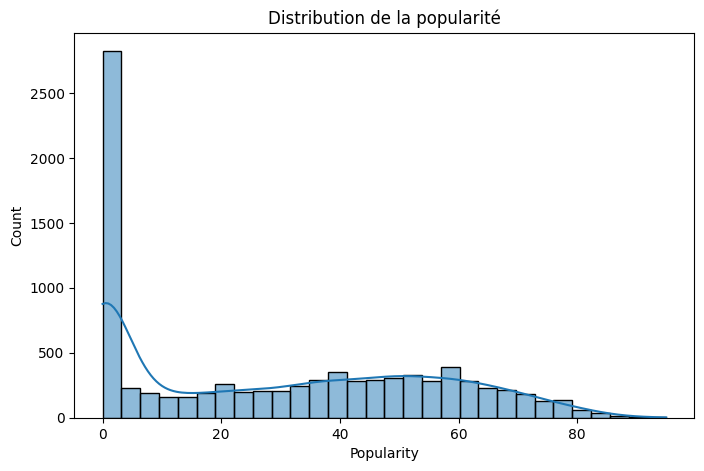

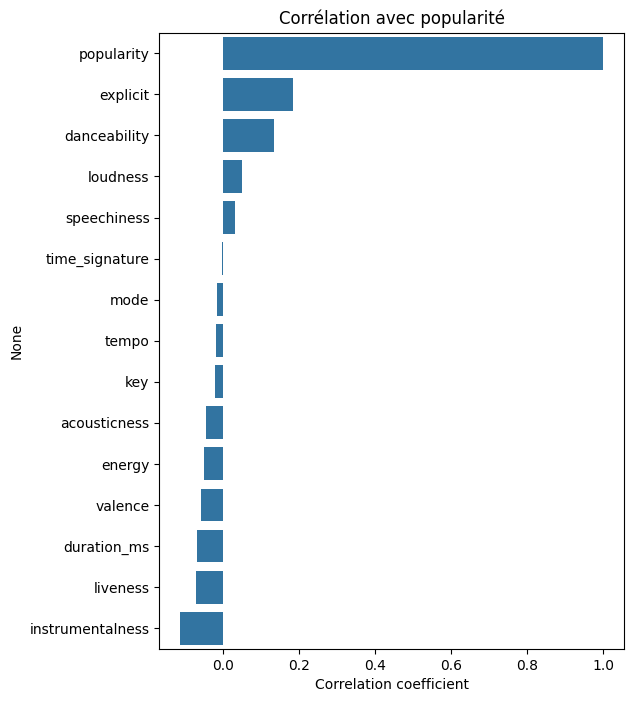

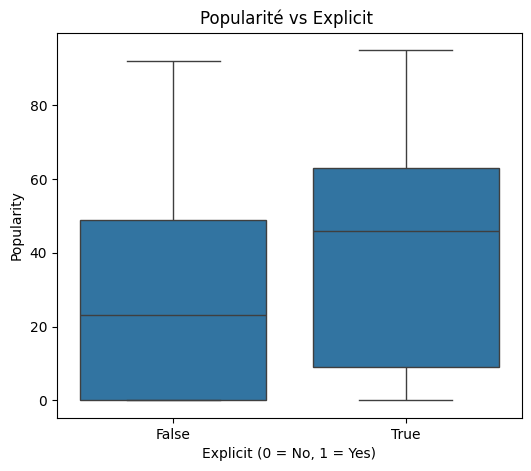

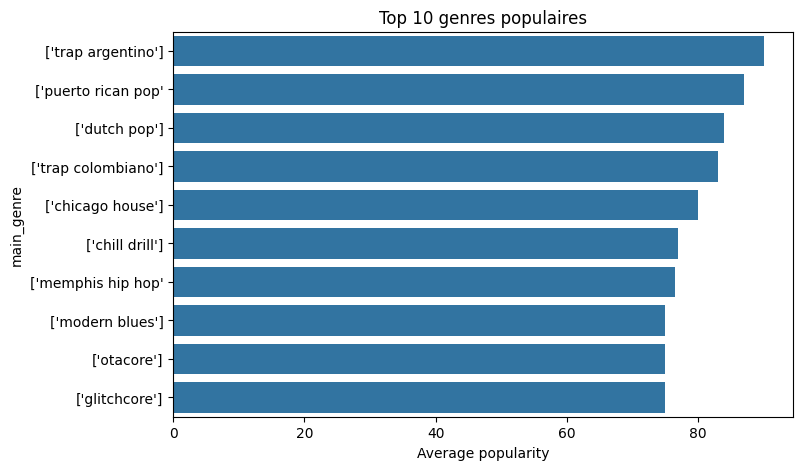

In [29]:
corr = df[features + ["popularity"]].corr()["popularity"].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.histplot(df["popularity"], bins=30, kde=True)
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.title("Distribution de la popularité")
plt.show()



plt.figure(figsize=(6, 8))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Corrélation avec popularité")
plt.xlabel("Correlation coefficient")
plt.show()



plt.figure(figsize=(6, 5))
sns.boxplot(x="explicit", y="popularity", data=df)
plt.xlabel("Explicit (0 = No, 1 = Yes)")
plt.ylabel("Popularity")
plt.title("Popularité vs Explicit ")
plt.show()



# On prend le premier genre comme genre principal
df["main_genre"] = df["genres"].str.split(",").str[0]

top_genres = (
    df.groupby("main_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.xlabel("Average popularity")
plt.title("Top 10 genres populaires")
plt.show()

Les résultats obtenus montrent que la popularité d’un morceau ne peut être expliquée uniquement par ses caractéristiques audio, ce qui souligne la complexité des dynamiques musicales.

Après avoir étudié des approches supervisées (classification et régression), nous abordons désormais une problématique différente : la recommandation musicale.  

L’Exercice 3 vise à construire un système capable de proposer des morceaux similaires en s’appuyant sur la notion de similarité entre caractéristiques audio.



### Exercice 3

L'objectif de cet exercice est de concevoir un système capable de suggérer des morceaux similaires à partir d'un titre de référence. 

Cette approche repose sur deux axes principaux :

- Analyse de contenu : Utiliser les caractéristiques acoustiques numériques (tempo, énergie, etc.) pour calculer la "proximité" mathématique entre les chansons.
- Algorithme des plus proches voisins : Implémenter un modèle capable d'identifier et de regrouper les titres les plus ressemblants pour générer une liste de lecture cohérente.

In [36]:
data = pd.read_csv(r"C:\Users\yanis\Documents\TP AARES\dataset_part_1\dataset\spotify_dataset_subset.csv")

numeric_features = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms", "time_signature"
]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[numeric_features])

knn_recommender = NearestNeighbors(n_neighbors=11, metric="cosine")
knn_recommender.fit(data_scaled)

def recommend_songs(song_name, knn_model, data, numeric_features):
    matches = data.index[data["track_name"] == song_name].tolist()
    
    if not matches:
        print(f"Chanson '{song_name}' non trouvée dans le dataset.")
        return None
    
    song_index = matches[0]
    song_features = data.loc[song_index, numeric_features].values.reshape(1, -1)
    song_features_scaled = scaler.transform(pd.DataFrame(song_features, columns=numeric_features))
    distances, indices = knn_model.kneighbors(song_features_scaled)
    
    base_name = data.loc[song_index, "track_name"]
    recommended_df = data.iloc[indices[0]][["artist_name", "track_name"]].copy()
    recommended_df = recommended_df[recommended_df["track_name"] != base_name]
    recommended_df = recommended_df.drop_duplicates(subset=["track_name"])
    recommended_df = recommended_df.head(10)
    
    return recommended_df.reset_index(drop=True)

song_name = "Westbound Train"
recommended_songs = recommend_songs(song_name, knn_recommender, data, numeric_features)
print("Chansons recommandées pour la chanson '{}':".format(song_name))
recommended_songs

Chanson 'Westbound Train' non trouvée dans le dataset.
Chansons recommandées pour la chanson 'Westbound Train':


## Partie 2

### Exercice 4

Cette section détaille la création d'une signature numérique robuste pour chaque signal sonore, permettant une identification fiable indépendamment des métadonnées.



#### 1. Analyse Temps-Fréquence
Nous transformons le signal audio brut en une représentation visuelle de son énergie :
* Outil : Utilisation de la STFT via la bibliothèque `librosa`.
* Paramètres : `win_length = 1024`, `n_fft = 2048`, `hop_length = 512`.
* Résultat : Un spectrogramme où l'énergie est répartie sur un plan temps-fréquence.

#### 2. Extraction des Points d'Intérêt
Pour stabiliser l'empreinte, nous isolons les éléments les plus marquants du spectre :
* Méthode : Identification des maxima locaux (pics d'énergie).
* Rôle : Ces points servent d'ancres robustes face aux bruits de fond ou aux distorsions.

#### 3. Algorithme de Hachage Combinatoire
L'originalité du système repose sur l'association de points pour créer des jetons uniques :
* Target Zone : Pour chaque ancre, nous définissons une zone de recherche de 300 pixels en temps et 20 pixels en fréquence.
* Sélection : Nous retenons les 10 maxima les plus élevés au sein de cette zone.
* Formule de calcul : 
  $$hash = anchor[0] \times 10^6 + point[0] \times 10^3 + point[1] - anchor[1]$$

> **Objectif** : Transformer des coordonnées physiques en objets de recherche performants pour la base de données.

#### 4.1

La première étape consiste à transformer le signal sonore brut en une représentation temps-fréquence exploitable via la fonction `compute_spectrogram(x)`.

* Chargement des données : Le signal audio est chargé avec un taux d'échantillonnage de **3000 Hz** (`sr=3000`) afin d'optimiser les ressources de calcul tout en conservant l'information fréquentielle essentielle.
* Transformation (STFT) : Nous appliquons une transformée de Fourier à court terme via la bibliothèque `librosa` avec les paramètres suivants :
    * `n_fft = 2048` : Taille de la fenêtre de Fourier.
    * `win_length = 1024` : Longueur de la fenêtre d'analyse.
    * `hop_length = 512` : Pas d'avancement entre chaque fenêtre.
* Résultat : Cette opération génère une matrice d'énergie $S$ (spectrogramme), où chaque cellule représente l'intensité d'une fréquence à un instant donné.



> **Note technique** : Ce paramétrage permet d'obtenir une résolution temporelle et fréquentielle équilibrée, indispensable pour extraire des points d'intérêt stables par la suite.

In [37]:
import librosa


In [38]:
def compute_spectrogram(x):
    S = librosa.stft(
        x,
        n_fft=2048,
        win_length=1024,
        hop_length=512
    )
    
    return np.abs(S)


#### 4.2

Cette étape vise à réduire la complexité du spectrogramme en ne conservant que les points les plus significatifs, qui constitueront les piliers de l'empreinte audio.

* Identification des pics : À l'aide de la fonction `get_maxima(S)`, nous isolons les maxima locaux du spectrogramme.
* Coordonnées temps-fréquence : Pour chaque pic détecté, nous extrayons sa position précise dans le plan (instant $t$, fréquence $f$).
* Stabilité : Ces maxima représentent les zones de forte concentration d'énergie, ce qui les rend particulièrement robustes aux bruits de fond et aux distorsions.



> **Résultat** : La variable `maxima` contient désormais une liste de coordonnées qui définissent la structure unique du morceau, transformant une image dense en un nuage de points caractéristiques exploitable pour le hachage.

In [40]:
import sys
sys.path.append(r"C:\Users\yanis\Documents\TP AARES")
from utils_projet import get_maxima
song, fs = librosa.load(r"C:\Users\yanis\Documents\TP AARES\songs_part_2\Classicals.de - Debussy - Children's Corner - I. Doctor Gradus ad Parnassum.wav", sr=3000)

S = compute_spectrogram(song)
maxima = get_maxima(S)
print(maxima)


c:\Users\yanis\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[[ 45 851]
 [ 50 369]
 [ 53 405]
 ...
 [905 831]
 [957 662]
 [957 706]]


#### 4.3

Cette étape permet de créer des relations entre les points d'intérêt en associant chaque maximum (anchor) à d'autres pics situés dans son voisinage temporel et fréquentiel.

* Paramétrage de la Target zone : Pour une ancre donnée, nous définissons une fenêtre de recherche s'étendant sur 300 pixels dans le futur (temps) et sur une plage de 40 pixels en fréquence (±20 pixels autour de l'ancre).
* Filtrage des points : La fonction `get_maxima_in_tz` parcourt la liste des maxima pour n'isoler que ceux tombant strictement à l'intérieur de cette zone.
* Sélection des meilleurs candidats : Les points trouvés sont triés par amplitude (énergie) afin de ne conserver que les 10 maxima les plus significatifs.



> **Rôle stratégique** : Cette sélection restreinte permet de générer des paires stables et répétables, essentielles pour construire des identifiants (hashes) uniques et résistants aux légères variations du signal.

In [41]:
def get_maxima_in_tz(S, maxima, anchor):
    
    anchor_freq = anchor[0]
    anchor_time = anchor[1]
    
    # Définir la Target Zone
    time_max = anchor_time + 300
    freq_min = anchor_freq - 20
    freq_max = anchor_freq + 20
    
    maxima_in_tz = []
    
    for point in maxima:
        freq = point[0]
        time = point[1]
        
        if (
            anchor_time < time <= time_max and
            freq_min <= freq <= freq_max
        ):
            maxima_in_tz.append(point)
    
    # Trier par amplitude décroissante
    maxima_in_tz = sorted(
        maxima_in_tz,
        key=lambda p: S[p[0], p[1]],
        reverse=True
    )
    
    return maxima_in_tz[:10]


#### 4.4

L'objectif de cette étape est de convertir les paires de points (ancre et points de la Target Zone) en objets mathématiques uniques et facilement indexables.

* Encodage Combinatoire : La fonction `get_hashes` traduit chaque paire de maxima en un identifiant unique (hash).
* Structure du Hash : On utilise une arithmétique précise pour intégrer les coordonnées temporelles et le décalage fréquentiel dans un seul entier :
  $$hash = anchor\_time \times 10^6 + point\_time \times 10^3 + (point\_freq - anchor\_freq)$$
* Indexation Temporelle : Chaque hash est stocké dans un dictionnaire associé à la position temporelle de son ancre (`anchor_time`).

> **Intérêt technique** : Cette méthode de hachage permet de compacter l'information audio. Au lieu de comparer des spectrogrammes entiers, le système compare de simples listes de nombres, ce qui accélère drastiquement la recherche en base de données.

In [42]:
def get_hashes(anchor, maxima_in_tz):
    
    hashes = {}
    
    anchor_freq = int(anchor[0])
    anchor_time = int(anchor[1])
    
    for point in maxima_in_tz:
        
        point_freq = int(point[0])
        point_time = int(point[1])
        
        hash_value = (
            anchor_time * 1000000 +
            point_time * 1000 +
            (point_freq - anchor_freq)
        )
        
        hashes[int(hash_value)] = anchor_time
    
    return hashes


In [43]:
anchor = maxima[0]
tz_points = get_maxima_in_tz(S, maxima, anchor)

hashes = get_hashes(anchor, tz_points)

print("Hashes:", hashes)


Hashes: {}


#### 4.5

Cette dernière étape de la partie 2 consiste à assembler toutes les fonctions précédentes au sein d'une procédure unique, capable de traiter l'intégralité d'un signal sonore pour en extraire son empreinte globale.

* Pipeline complet : La fonction `process_signal` orchestre le flux de données en calculant successivement le spectrogramme, en isolant les maxima, puis en générant les hashes pour chaque point d'ancrage.
* Agrégation des données : Pour chaque ancre identifiée, le système récupère les points de la zone cible et calcule les hashes correspondants, qui sont ensuite fusionnés dans un dictionnaire unique `song_hashes`.
* Résultat final : La fonction retourne un dictionnaire complet où chaque clé est un hash unique associé à sa position temporelle.



> **Bilan de l'étape** : Grâce à cette automatisation, nous passons d'un traitement point par point à une extraction globale. Le nombre de hashes générés témoigne de la richesse de la signature numérique, garantissant ainsi une identification précise lors de la phase de recherche.

In [44]:
def process_signal(x):
    
    S = compute_spectrogram(x)
    maxima = get_maxima(S)
    
    song_hashes = {}
    
    for anchor in maxima:
        
        tz_points = get_maxima_in_tz(S, maxima, anchor)
        hashes = get_hashes(anchor, tz_points)
        
        song_hashes.update(hashes)
    
    return song_hashes


In [45]:
song_hashes = process_signal(song)

print("Nombre de hash générés :", len(song_hashes))


Nombre de hash générés : 9689


Une fois l'architecture algorithmique établie et les fonctions de génération d'empreintes définies dans l'exercice précédent , nous allons maintenant mettre en œuvre ces outils pour constituer une base de données de référence et valider l'efficacité du système de recherche sur des extraits audio réels

### Exercice 5 : Création de la base de données et recherche

L'objectif de cette étape finale est de transformer nos fonctions de traitement en un système opérationnel d'identification audio. Nous passons ici de l'analyse d'un signal unique à la gestion d'une base de données de référence.

#### Enjeux de l'exercice :
* Structuration des données : Automatiser le traitement de l'ensemble d'un catalogue musical pour stocker leurs empreintes (hashes) dans une structure de données indexée.
* Persistance : Utiliser la sérialisation pour sauvegarder la base de données et permettre des recherches ultérieures sans recalcul complet.
* Moteur de recherche : Implémenter une logique de comparaison robuste capable d'identifier un morceau à partir d'un court extrait (5 à 15 secondes).



Cette phase permet de valider la fiabilité de notre algorithme de fingerprinting en conditions réelles, en vérifiant si la corrélation temporelle des hashes permet de retrouver le morceau correct parmi l'ensemble du jeu de données.

#### 1. Chargement et préparation de la base de données musicale

Pour construire notre moteur de recherche, la première étape indispensable consiste à collecter et charger l'intégralité des morceaux de référence. On commence par parcourir l'arborescence du dossier contenant les fichiers audio en filtrant uniquement les formats compatibles (.mp3 et .wav). Une fois cette liste de chemins établie, on procède au chargement effectif de chaque chanson en utilisant un taux d'échantillonnage uniforme de 3000 Hz. Cette étape permet de normaliser toutes nos données d'entrée, créant ainsi une collection de signaux numériques prêts à être transformés en empreintes (hashes). En automatisant ce processus, on s'assure que notre base de données sera exhaustive et traitée de manière rigoureuse avant l'étape de fingerprinting.

In [46]:
import os
dataset_path = r"C:\Users\yanis\Documents\TP AARES\songs_part_2"
song_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".mp3") or file.endswith(".wav"):
            song_files.append(os.path.join(root, file))
print(f"Nombre de fichiers trouvés : {len(song_files)}")


songs = []
for file in song_files:
    song, fs = librosa.load(file, sr=3000)
    songs.append(song)
print(f"Nombre de chansons chargées : {len(songs)}")



Nombre de fichiers trouvés : 13
Nombre de chansons chargées : 13


#### 2. Génération des empreintes pour l'ensemble du catalogue

Une fois que tous les signaux audio sont chargés et normalisés, on procède à la phase de "fingerprinting" massif de notre bibliothèque. Pour chaque morceau de la collection, on fait appel à la fonction `process_signal` qui se charge d'extraire les points d'intérêt et de les transformer en une liste de hashes uniques. L'objectif ici est de convertir des fichiers audio volumineux en une série de signatures numériques compactes et représentatives. On stocke ensuite ces résultats dans une structure globale appelée `all_hashes`, qui servira de base de données de référence. Cette étape transforme ainsi notre simple dossier de fichiers musicaux en un index structuré, permettant une comparaison quasi instantanée lors de la phase de recherche.



In [47]:
all_hashes = []
for song in songs:
    song_hashes = process_signal(song)
    all_hashes.append(song_hashes)
print(f"Nombre de chansons traitées : {len(all_hashes)}")



Nombre de chansons traitées : 13


#### 3. Sauvegarde et persistance de la base de données

Afin d'éviter de devoir recalculer les empreintes à chaque session, ce qui serait particulièrement coûteux en temps pour de grandes bibliothèques, on utilise la bibliothèque `pickle` pour sérialiser la liste des dictionnaires de hachages. Cette étape de sauvegarde crée un fichier binaire nommé `song_hashes.pkl` qui contient l'intégralité de la structure `all_hashes`. En enregistrant les données sous ce format, on garantit la persistance de notre travail : la base de données peut désormais être rechargée instantanément lors de futures utilisations du moteur de recherche. Enfin, un affichage de contrôle de la première entrée de la liste permet de vérifier que la structure des hachages (clés et positions temporelles) est correctement formée avant la finalisation.



In [48]:
import pickle
with open("song_hashes.pkl", "wb") as f:
    pickle.dump(all_hashes, f)
print("Dictionnaires de hachages sauvegardés dans song_hashes.pkl")

print(dict(list(all_hashes[0].items())[:10]))



Dictionnaires de hachages sauvegardés dans song_hashes.pkl
{41272001: 41, 41085002: 41, 41324002: 41, 41174001: 41, 41246001: 41, 41095003: 41, 41136001: 41, 41159002: 41, 41336002: 41, 41301000: 41}


#### 4. Extraction et préparation d'un échantillon de test

Pour tester l'efficacité de notre moteur de recherche, on simule une requête utilisateur en extrayant un court segment d'un morceau existant. On charge ainsi un extrait de 10 secondes, prélevé après 30 secondes de lecture, en respectant rigoureusement le taux d'échantillonnage de 3000 Hz utilisé pour la base de données de référence. Ce signal court constitue notre "requête" : il est désormais prêt à être transformé en empreinte numérique via le même processus de hachage, afin de vérifier si le système est capable de l'identifier correctement parmi tous les titres stockés.


In [49]:
import librosa

path_to_song = r"C:\Users\yanis\Documents\TP AARES\DiaYiannopoulou-ZeroProject-LastDance.wav"

excerpt, fs = librosa.load(path_to_song, sr=3000, offset=30.0, duration=10.0)



#### 5. Fingerprinting de l'extrait de requête

Une fois l'échantillon sonore chargé, on lui applique la fonction `process_signal` afin d'en extraire sa signature numérique spécifique. Cette étape permet de transformer les 10 secondes d'audio en un dictionnaire de hashes, exactement selon la même méthode que celle utilisée pour les morceaux de la base de données.


In [50]:
excerpt_hashes = process_signal(excerpt)
print(f"Nombre de hash générés pour l'extrait : {len(excerpt_hashes)}")

Nombre de hash générés pour l'extrait : 196


#### 6. Identification finale et recherche par corrélation

La dernière étape consiste à confronter l'empreinte de notre extrait à l'ensemble de la base de données via la fonction `search_song`. Après avoir rechargé nos dictionnaires de hachages préalablement sauvegardés, l'algorithme compare les signatures numériques en cherchant les hashes communs, et une cohérence dans leur alignement temporel. Le système identifie ainsi les trois morceaux les plus ressemblants et retourne leurs indices. Cette phase de test permet de valider concrètement la fiabilité du moteur de recherche : en vérifiant si l'indice du morceau original figure parmi les meilleures prédictions, on confirme la capacité de notre application à reconnaître une musique même à partir d'un segment partiel et décalé dans le temps.


In [51]:
from utils_projet import search_song

with open('song_hashes.pkl', 'rb') as handle:# optionnel en soit uniquement si jamais on a pas déjà chargé les hachages avec ici la fonction all_hashes 
          dataset = pickle.load(handle)
db_hashes = all_hashes 
indices = search_song(db_hashes, excerpt_hashes)
print("Indices of the three most similar songs:", indices)



Indices of the three most similar songs: [11  3  0]


Nous chargeons la base des hashes des chansons puis comparons les empreintes d’un extrait aux empreintes du dataset.  
Les morceaux sont classés selon le nombre de correspondances, et nous affichons les trois plus similaires afin de vérifier si la chanson correcte apparaît parmi eux.


### Exercice 6 : Évaluation de l'incertitude (Conformal Prediction)

L'objectif de cet exercice est de quantifier la fiabilité de notre classification de genres en utilisant la prédiction conforme. Contrairement à une prédiction classique, cette méthode génère des intervalles de confiance basés sur la similarité entre les nouvelles données et le jeu d'entraînement.

####  Méthodologie
* Modèle : Utilisation d'un classifieur KNN entraîné sur un échantillon limité à 1500 exemples pour optimiser les performances.
* Outil : Classe `ConformalPrediction` permettant de calculer les scores de non-conformité pour chaque point de test.
* Prétraitement : Application d'un `StandardScaler` dédié aux caractéristiques du genre pour garantir l'intégrité des calculs de distance.






On réalise les implémentations nécessaires 

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from utils_projet import ConformalPrediction

#### 1. Introduction et Calibration du Prédicteur
L'objectif est de quantifier l'incertitude de notre modèle KNN en utilisant la prédiction conforme. Cette méthode produit des intervalles de confiance garantissant que le vrai genre appartient à l'ensemble prédit avec une probabilité fixée (ex: 95%). 
* Calibration : Nous utilisons un échantillon de 1500 données pour calculer les scores de non-conformité.
* Modèle : Un classifieur KNN (K=5) sert de base à l'évaluation de l'incertitude.

In [53]:

# On recharge le dataset de l'exercice 1 pour éviter les conflits avec l'exo de popularité

df_genre = pd.read_csv(r"C:\Users\yanis\Documents\TP AARES\dataset_part_1\dataset\spotify_dataset_train.csv")

# Nettoyage identique à l'exercice 1
y_genre = df_genre["genre"]
X_genre = df_genre.drop(columns=["genre", "release_date"])

# Split pour obtenir un set de test/validation propre
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_genre, y_genre, test_size=0.2, random_state=10, stratify=y_genre)

In [54]:
# On limite à 1500 exemples comme demandé pour la performance

n_limit = 1500
X_small = X_train_g[:n_limit]
y_small = y_train_g[:n_limit]

# Normalisation spécifique aux données de genre

scaler_g = StandardScaler()
X_small_scaled = scaler_g.fit_transform(X_small)
X_test_scaled = scaler_g.transform(X_test_g)

In [55]:

knn_conformal = KNeighborsClassifier(n_neighbors=5)
knn_conformal.fit(X_small_scaled, y_small)

predictor = ConformalPrediction(knn_conformal, X_small_scaled, y_small)

#### 2. Analyse de l'incertitude à 95% de confiance
En fixant un risque d'erreur $\epsilon = 0.05$, nous observons que les intervalles de prédiction sont particulièrement larges (contenant parfois plus de 15 genres). 
* Constat : Pour garantir une fiabilité de 95%, le modèle doit inclure une vaste gamme de styles musicaux. 
* Interprétation : Cela souligne la porosité des frontières acoustiques entre les genres musicaux dans le dataset Spotify.

In [56]:

# On va tester sur les 5 premières chansons du set de test

for i in range(5):
    x_new = X_test_scaled[i]
    true_genre = y_test_g.iloc[i]
    
    print(f"\n--- Analyse de la chanson n°{i+1} (Genre réel : {true_genre}) ---")
    
    # Calcul des scores
    predictor.predict(x_new)
    
    # 95% de confiance (eps = 0.05)
    interval_95 = predictor.compute_interval(0.05)
    print(f"Intervalle à 95% (eps=0.05) : {interval_95}")
    
    # Recherche du niveau de confiance pour un genre unique
    eps_unique = 0.05
    while len(predictor.compute_interval(eps_unique)) > 1 and eps_unique < 0.95:
        eps_unique += 0.05
    
    final_genre = predictor.compute_interval(eps_unique)
    confidence = (1 - eps_unique) * 100
    print(f"Genre unique prédit : {final_genre}")
    print(f"Niveau de confiance pour ce genre unique : {confidence:.1f}%")


--- Analyse de la chanson n°1 (Genre réel : hip hop) ---
blues
chanson
classical
country
dance
disco
edm
electro
folk
hip hop
jazz
latin
metal
pop
punk
r&b
rap
reggae
rock
salsa
soul
techno
Intervalle à 95% (eps=0.05) : ['blues', 'chanson', 'disco', 'edm', 'electro', 'hip hop', 'jazz', 'latin', 'metal', 'pop', 'punk', 'r&b', 'rap', 'reggae', 'salsa', 'soul']
Genre unique prédit : ['hip hop']
Niveau de confiance pour ce genre unique : 30.0%

--- Analyse de la chanson n°2 (Genre réel : latin) ---
blues
chanson
classical
country
dance
disco
edm
electro
folk
hip hop
jazz
latin
metal
pop
punk
r&b
rap
reggae
rock
salsa
soul
techno
Intervalle à 95% (eps=0.05) : ['blues', 'chanson', 'country', 'dance', 'disco', 'edm', 'electro', 'hip hop', 'jazz', 'latin', 'pop', 'punk', 'r&b', 'rap', 'reggae', 'rock', 'salsa', 'soul', 'techno']
Genre unique prédit : []
Niveau de confiance pour ce genre unique : 15.0%

--- Analyse de la chanson n°3 (Genre réel : pop) ---
blues
chanson
classical
country
dance


#### 3. Effet de l'augmentation du risque ($\epsilon$)
Lorsque l'on augmente $\epsilon$, la taille de l'intervalle diminue mécaniquement. 
* Convergence : En acceptant plus d'erreurs, le modèle ne conserve que les genres les plus proches acoustiquement.


####  Analyse des résultats
* Influence de $\epsilon$ : À $\epsilon = 0.05$ (confiance 95%), l'intervalle est large et contient souvent plusieurs genres. En augmentant $\epsilon$, l'intervalle se réduit car on accepte un risque d'erreur plus élevé.
* Similarité sémantique : Les genres regroupés dans un même intervalle sont souvent acoustiquement proches (ex: Pop et Dance), confirmant la cohérence du modèle.
* Indice de confiance : En ajustant $\epsilon$ pour obtenir un genre unique, on peut attribuer un pourcentage de certitude précis à chaque prédiction ($1 - \epsilon$).


**Conclusion** : Cette approche permet d'identifier les morceaux "ambigus" et de ne valider les prédictions que lorsqu'un seuil de confiance suffisant est atteint, rendant le système de classification plus robuste et transparent.